# Hallucination Classifier v2: TF-IDF + Handcrafted Features
### Supervised Learning Project

This notebook extends the baseline classifier by adding **10 handcrafted linguistic features** alongside TF-IDF.
We then run an **ablation study** to measure exactly how much these features help.

**Models:** Logistic Regression, Random Forest
**New:** Hedge word density, number density, named entity proxy, QA similarity, and more.


In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)

import warnings
warnings.filterwarnings('ignore')


## Step 1: Data Loading & Preprocessing
Same setup as the baseline notebook — we load HaluEval QA and create 20,000 labeled samples.
We also track `orig_idx` so each correct/hallucinated pair can be linked back to its source question.


In [2]:
print("Loading HaluEval QA dataset...")
dataset = load_dataset("pminervini/HaluEval", "qa", split='data')
df = dataset.to_pandas()

correct_df = df[['question', 'right_answer']].copy()
correct_df.rename(columns={'right_answer': 'answer'}, inplace=True)
correct_df['label'] = 0
correct_df['orig_idx'] = range(len(df))

hallucinated_df = df[['question', 'hallucinated_answer']].copy()
hallucinated_df.rename(columns={'hallucinated_answer': 'answer'}, inplace=True)
hallucinated_df['label'] = 1
hallucinated_df['orig_idx'] = range(len(df))

full_df = pd.concat([correct_df, hallucinated_df]).sample(frac=1, random_state=42).reset_index(drop=True)
full_df['text'] = ("Question: " + full_df['question'] + " Answer: " + full_df['answer']).str.lower()

print(f"Total samples: {len(full_df)}")
print(f"Class distribution:\n{full_df['label'].value_counts(normalize=True)}")
full_df.head(3)


Loading HaluEval QA dataset...


Total samples: 20000
Class distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


,question,answer,label,orig_idx,text
0,Which 2004 Nickelodeon show was created by Sue...,"The animated series ""Pepper Ann"" and ""Angela A...",1,650,question: which 2004 nickelodeon show was crea...
1,Non-Stop starred the English actress best know...,Lady Mary Crawley,0,2041,question: non-stop starred the english actress...
2,Cross country running is a sport in which team...,dirt or grass,0,8668,question: cross country running is a sport in ...


## Step 2: Handcrafted Linguistic Feature Engineering

We engineer 10 scalar features per sample that capture linguistic signals of hallucination:

| Feature | Intuition |
|---|---|
| `answer_length` | Hallucinated answers tend to pad with filler words |
| `hedge_density` | "might/could/possibly" signals uncertainty |
| `number_density` | Specific numbers = more factually grounded |
| `unique_word_ratio` | Low ratio = repetitive/padded answer |
| `capital_word_ratio` | Proxy for named entity density |
| `avg_word_length` | Domain-specific vocab uses longer words |
| `length_ratio` | Is the answer proportionally detailed vs the question? |
| `sentence_count` | Structural complexity |
| `word_overlap` | Do answer and question share key vocabulary? |
| `qa_tfidf_similarity` | Is the answer just echoing the question? |


In [3]:
HEDGE_WORDS = {
    'might', 'could', 'possibly', 'perhaps', 'probably', 'approximately',
    'around', 'roughly', 'seems', 'appears', 'likely', 'unlikely',
    'maybe', 'sometimes', 'often', 'generally', 'usually', 'suggest',
    'believe', 'thought', 'assumed', 'estimated'
}

def build_handcrafted_features(df, qa_vec=None):
    """
    Compute 10 handcrafted linguistic features per sample.
    qa_vec: fitted TfidfVectorizer for QA similarity. If None, fit on df.
    Returns: (feature_array [n x 10], fitted qa_vec)
    """
    answers  = df['answer'].fillna('').astype(str).tolist()
    questions = df['question'].fillna('').astype(str).tolist()

    rows = []
    for ans, que in zip(answers, questions):
        a_words = ans.lower().split()
        q_words = que.lower().split()
        n_a = max(len(a_words), 1)
        n_q = max(len(q_words), 1)
        sents = [s.strip() for s in re.split(r'[.!?]+', ans) if s.strip()]

        rows.append([
            float(n_a),
            sum(1 for w in a_words if w in HEDGE_WORDS) / n_a,
            sum(1 for w in a_words if re.search(r'\d', w)) / n_a,
            len(set(a_words)) / n_a,
            sum(1 for w in ans.split() if w and w[0].isupper()) / n_a,
            float(np.mean([len(w) for w in a_words])),
            n_a / n_q,
            float(len(sents)),
            len(set(q_words) & set(a_words)) / n_q,
        ])

    feat_array = np.array(rows, dtype=np.float64)

    # QA TF-IDF cosine similarity (TF-IDF uses L2 norm, so dot product = cosine sim)
    if qa_vec is None:
        qa_vec = TfidfVectorizer(max_features=2000, stop_words='english')
        qa_vec.fit(questions + answers)

    q_vecs = qa_vec.transform(questions)
    a_vecs = qa_vec.transform(answers)
    qa_sim = np.asarray(q_vecs.multiply(a_vecs).sum(axis=1)).flatten()

    feat_array = np.column_stack([feat_array, qa_sim])  # [n x 10]
    return feat_array, qa_vec

HANDCRAFTED_NAMES = [
    'answer_length', 'hedge_density', 'number_density', 'unique_word_ratio',
    'capital_ratio', 'avg_word_length', 'length_ratio', 'sentence_count',
    'word_overlap', 'qa_tfidf_similarity'
]

print("Handcrafted feature engineering function defined.")
print(f"Features: {HANDCRAFTED_NAMES}")


Handcrafted feature engineering function defined.
Features: ['answer_length', 'hedge_density', 'number_density', 'unique_word_ratio', 'capital_ratio', 'avg_word_length', 'length_ratio', 'sentence_count', 'word_overlap', 'qa_tfidf_similarity']


## Step 3: TF-IDF + Feature Combination

We first split the data, then fit all transformers **on training data only** to prevent data leakage.
The final feature matrix combines the 5000 TF-IDF features with the 10 handcrafted features.


In [4]:
# 80/20 stratified split on the dataframe first
train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['label'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df['label'].values
y_test  = test_df['label'].values

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# TF-IDF (fit on train only)
print("Fitting TF-IDF on training data...")
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_tfidf_train = tfidf_vec.fit_transform(train_df['text'])
X_tfidf_test  = tfidf_vec.transform(test_df['text'])

# Handcrafted features (fit qa_vec on train only)
print("Computing handcrafted features...")
X_hand_train, qa_vec = build_handcrafted_features(train_df)
X_hand_test,  _      = build_handcrafted_features(test_df, qa_vec=qa_vec)

# Scale handcrafted features (fit scaler on train only)
scaler = StandardScaler()
X_hand_train_s = scaler.fit_transform(X_hand_train)
X_hand_test_s  = scaler.transform(X_hand_test)

# Combine into one sparse matrix
X_train_combined = hstack([X_tfidf_train, csr_matrix(X_hand_train_s)])
X_test_combined  = hstack([X_tfidf_test,  csr_matrix(X_hand_test_s)])

print(f"\nTF-IDF only shape:   {X_tfidf_train.shape}")
print(f"Combined shape:      {X_train_combined.shape}")


Train: 16000 | Test: 4000
Fitting TF-IDF on training data...


Computing handcrafted features...



TF-IDF only shape:   (16000, 5000)
Combined shape:      (16000, 5010)


## Step 4: Model Training
We train Logistic Regression and Random Forest on the **combined** feature set.


In [5]:
print("Training Logistic Regression (combined features)...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_combined, y_train)

print("Training Random Forest (combined features)...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_combined, y_train)

print("Training complete.")


Training Logistic Regression (combined features)...
Training Random Forest (combined features)...


Training complete.


## Step 5: Evaluation


In [6]:
def evaluate_model(name, model, X_test, y_test):
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba)
    }, y_pred, y_pred_proba

lr_metrics, lr_preds, lr_proba = evaluate_model("LR (Combined)", lr_model, X_test_combined, y_test)
rf_metrics, rf_preds, rf_proba = evaluate_model("RF (Combined)", rf_model, X_test_combined, y_test)

pd.DataFrame([lr_metrics, rf_metrics])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LR (Combined),0.94675,0.961757,0.9305,0.945870,0.977580
1,RF (Combined),0.94875,0.972120,0.9240,0.947449,0.976348


## Step 6: Ablation Study — Does Adding Handcrafted Features Help?

We retrain both models on **TF-IDF only** to measure the exact contribution of our handcrafted features.


In [7]:
# TF-IDF only baseline
print("Training baseline models (TF-IDF only)...")
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_tfidf_train, y_train)

rf_base = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_base.fit(X_tfidf_train, y_train)

lr_base_metrics, _, _ = evaluate_model("LR (TF-IDF only)",  lr_base, X_tfidf_test, y_test)
rf_base_metrics, _, _ = evaluate_model("RF (TF-IDF only)",  rf_base, X_tfidf_test, y_test)

ablation_df = pd.DataFrame([
    lr_base_metrics, lr_metrics,
    rf_base_metrics, rf_metrics
])
ablation_df['Delta F1'] = ablation_df.groupby(ablation_df.index // 2)['F1 Score'].transform(lambda x: x - x.iloc[0])
print(ablation_df[['Model', 'Accuracy', 'F1 Score', 'ROC-AUC', 'Delta F1']].to_string(index=False))


Training baseline models (TF-IDF only)...


           Model  Accuracy  F1 Score  ROC-AUC  Delta F1
LR (TF-IDF only)   0.67000  0.668508 0.728551  0.000000
   LR (Combined)   0.94675  0.945870 0.977580  0.277362
RF (TF-IDF only)   0.73650  0.721606 0.801306  0.000000
   RF (Combined)   0.94875  0.947449 0.976348  0.225843


## Step 7: Visualizations


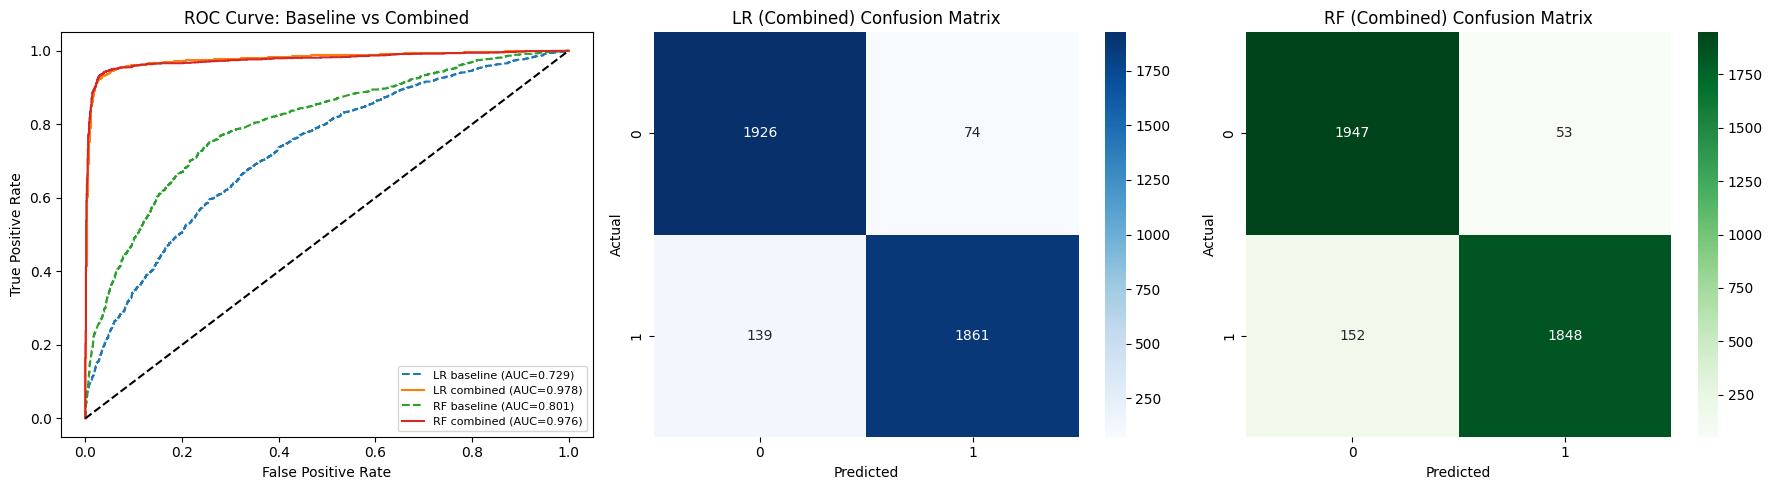

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves: baseline vs combined for LR
lr_base_proba = lr_base.predict_proba(X_tfidf_test)[:, 1]
rf_base_proba = rf_base.predict_proba(X_tfidf_test)[:, 1]

fpr_lr_base, tpr_lr_base, _ = roc_curve(y_test, lr_base_proba)
fpr_lr,      tpr_lr,      _ = roc_curve(y_test, lr_proba)
fpr_rf_base, tpr_rf_base, _ = roc_curve(y_test, rf_base_proba)
fpr_rf,      tpr_rf,      _ = roc_curve(y_test, rf_proba)

axes[0].plot(fpr_lr_base, tpr_lr_base, '--', label=f"LR baseline (AUC={lr_base_metrics['ROC-AUC']:.3f})")
axes[0].plot(fpr_lr,      tpr_lr,            label=f"LR combined (AUC={lr_metrics['ROC-AUC']:.3f})")
axes[0].plot(fpr_rf_base, tpr_rf_base, '--', label=f"RF baseline (AUC={rf_base_metrics['ROC-AUC']:.3f})")
axes[0].plot(fpr_rf,      tpr_rf,            label=f"RF combined (AUC={rf_metrics['ROC-AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC Curve: Baseline vs Combined')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

# Confusion matrices
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('LR (Combined) Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_title('RF (Combined) Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Step 8: Handcrafted Feature Importance
Which of our 10 handcrafted features contributed most to the Logistic Regression decision?


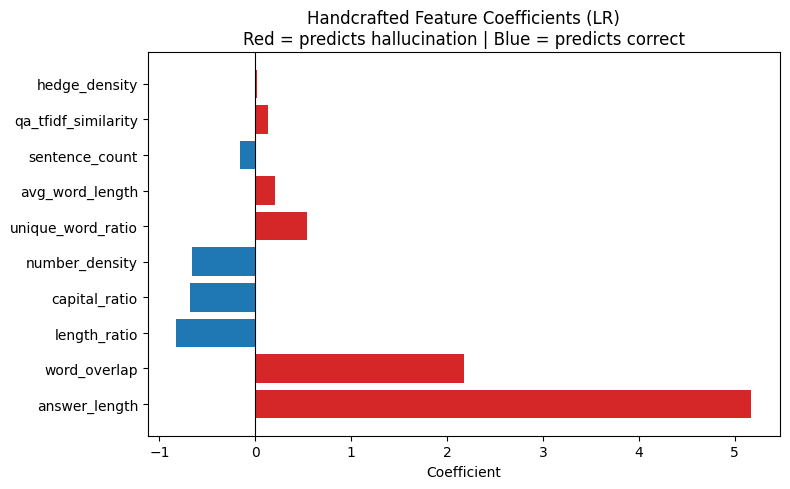


Handcrafted feature coefficients:
            Feature  Coefficient
      answer_length     5.172197
       word_overlap     2.181978
       length_ratio    -0.820883
      capital_ratio    -0.675177
     number_density    -0.660399
  unique_word_ratio     0.538544
    avg_word_length     0.210182
     sentence_count    -0.158274
qa_tfidf_similarity     0.136654
      hedge_density     0.019272


In [9]:
# The handcrafted features are the LAST 10 columns of the combined feature matrix
all_feature_names = list(tfidf_vec.get_feature_names_out()) + HANDCRAFTED_NAMES
lr_coefs = lr_model.coef_[0]

# Handcrafted features only
hand_coef_df = pd.DataFrame({
    'Feature':     HANDCRAFTED_NAMES,
    'Coefficient': lr_coefs[-10:]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in hand_coef_df['Coefficient']]
ax.barh(hand_coef_df['Feature'], hand_coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Handcrafted Feature Coefficients (LR)\nRed = predicts hallucination | Blue = predicts correct')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print("\nHandcrafted feature coefficients:")
print(hand_coef_df.to_string(index=False))


## Conclusion

This notebook shows whether handcrafted linguistic features — hedge word density, number density,
named entity proxies, and more — add discriminative signal on top of TF-IDF for hallucination detection.

The ablation study in Step 6 gives a clean answer: **by how many F1 points do our features improve over TF-IDF alone?**
The feature importance plot in Step 8 reveals which linguistic patterns are most predictive.

Next: see `hallucination_regression.ipynb` for the regression formulation.
